Loading existing baseline grid from 'c:\Users\matas\Desktop\CurrentSetpoints\data\IEETIE_machine2_baseline.pkl'...
Plotting Baseline Grid...


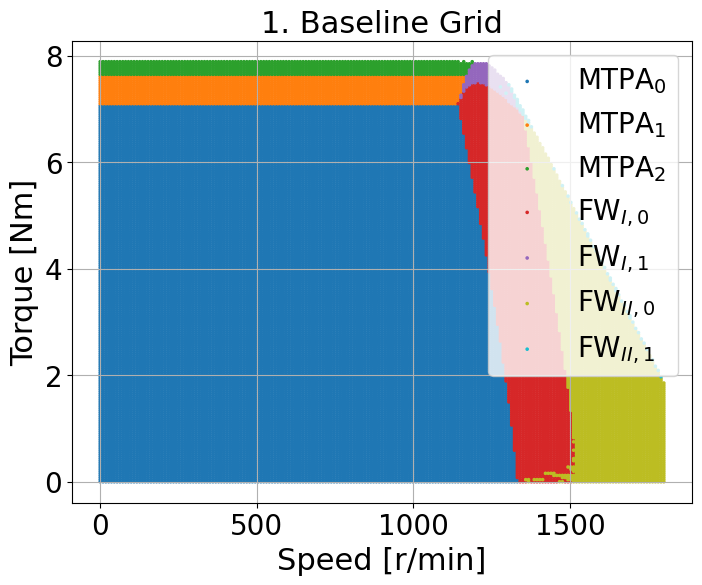

In [3]:
import os
import pickle
import sys

root_dir = os.path.abspath("..")
package_dir = os.path.abspath(os.path.join(root_dir, "current_setpoints"))
optimization_dir = os.path.abspath(os.path.join(package_dir, "optimization"))
model_dir = os.path.abspath(os.path.join(package_dir, "model"))
data_dir = os.path.join(root_dir, "data")

os.makedirs(data_dir, exist_ok=True)

for path in [root_dir, package_dir, optimization_dir, model_dir]:
    if path not in sys.path:
        sys.path.append(path)

from current_setpoints.data import FluxValues, IEEEMachine2
from current_setpoints.model import Transform
from current_setpoints.optimization import (
    ModelAnalytical,
    MotorOptimizer,
    calculate_grid,
    grid_to_data,
)
from current_setpoints.utils.plotting import plot_grid_segments

flux_registry = FluxValues()
machine = IEEEMachine2(flux_values=flux_registry)

nmax = 1800
machine.set_max_pars(curr_max=30.0, volt_max=13.0, omega_max=nmax)
transform = Transform(machine=machine, omega=0.0, add_volt_0=False)

analytical_model = ModelAnalytical(machine=machine)
solver_opts = {"disp": False, "ftol": 1e-8, "maxiter": 500, "eps": 1e-8}
optimizer = MotorOptimizer(model=analytical_model, opts=solver_opts)

grid_opts = {"n_torq": 201, "n_omega": 201, "torq_min": 0.0, "omega_min": 0.0}
filename = os.path.join(data_dir, "IEETIE_machine2_baseline.pkl")

if os.path.isfile(filename):
    print(f"Loading existing baseline grid from '{filename}'...")
    with open(filename, "rb") as file:
        grid_result = pickle.load(file)
else:
    print("Starting baseline grid calculation. This may take a few minutes...")
    grid_result = calculate_grid(
        optimizer=optimizer, transform=transform, opts=grid_opts, mode="standard"
    )
    with open(filename, "wb") as file:
        pickle.dump(grid_result, file)
    print(f"Baseline Grid successfully calculated and saved to '{filename}'")

print("Plotting Baseline Grid...")
machine_data = grid_to_data(grid_result, k_skip=1)
plot_grid_segments(machine_data, title="1. Baseline Grid")